# Analyse single-cell RNA-seq — PBMC 3k
Dataset : 2700 cellules sanguines humaines (10x Genomics)
Objectif : identifier les types cellulaires par clustering non supervisé

## 1. Chargement des données
On charge le dataset PBMC 3k directement depuis Scanpy.
La donnée brute est une matrice cellules × gènes (2700 cellules, ~33 000 gènes).

import scanpy as sc

adata = sc.datasets.pbmc3k()
print(adata)

In [11]:
%matplotlib inline

## 2. Quality Control
On filtre les cellules de mauvaise qualité :
- Cellules avec trop peu de gènes → cellules mortes ou vides
- Cellules avec trop de gènes → doublets (2 cellules capturées ensemble)
- Cellules avec trop d'ARN mitochondrial (> 5%) → cellules en train de mourir

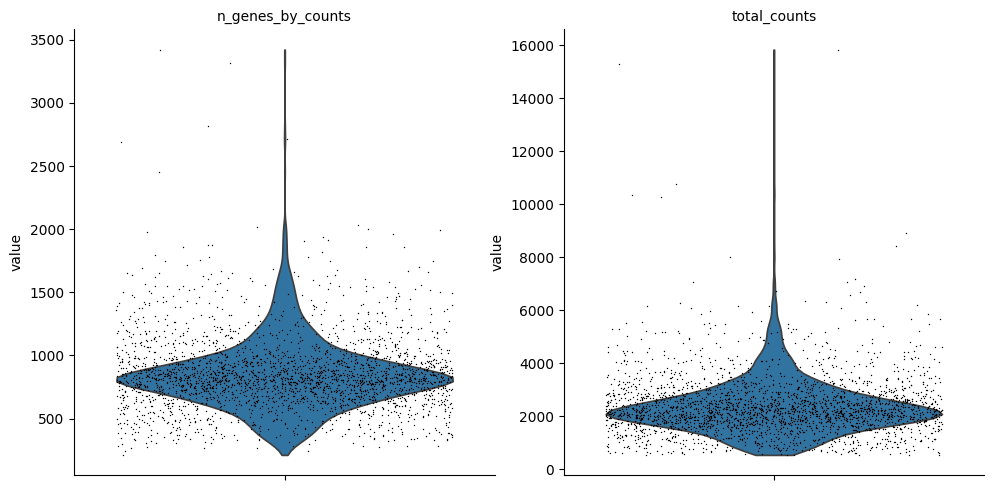

In [14]:
import matplotlib.pyplot as plt

sc.pp.calculate_qc_metrics(adata, inplace=True)
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts'], jitter=0.4, multi_panel=True) 

In [18]:
adata.to_df().head(20)

index,MIR1302-10,FAM138A,OR4F5,RP11-34P13.7,RP11-34P13.8,AL627309.1,RP11-34P13.14,RP11-34P13.9,AP006222.2,RP4-669L17.10,...,KIR3DL2-1,AL590523.1,CT476828.1,PNRC2-1,SRSF10-1,AC145205.1,BAGE5,CU459201.1,AC002321.2,AC002321.1
index,,,,,,,,,,,,,,,,,,,,,
AAACATACAACCAC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACATTGAGCTAC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACATTGATCAGC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCGTGCTTCCG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCGTGTATGCG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACGCACTGGTAC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACGCTGACCAGT-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACGCTGGTTCTT-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACGCTGTAGCCA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Filtrage

In [25]:
# avant filtrage 
print("Avant filtrage: ", adata.shape)

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

print("Après filtrage: ", adata.shape)

Avant filtrage:  (2700, 13714)
Après filtrage:  (2700, 13714)


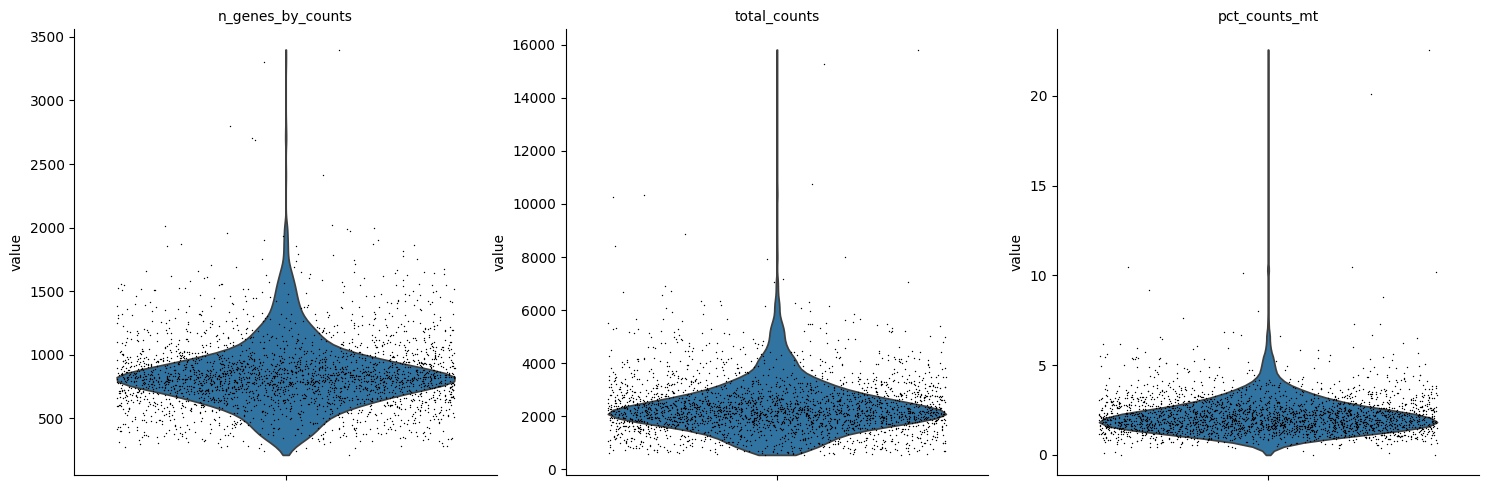

In [28]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')

sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True)

In [29]:
# Filtrer les cellules aberrantes
adata = adata[adata.obs.n_genes_by_counts < 2500, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]

print("Après filtrage qualité:", adata.shape)

Après filtrage qualité: (2638, 13714)


## 3. Normalisation
Chaque cellule a capturé un nombre différent de molécules d'ARN.
On ramène tout le monde à 10 000 counts pour pouvoir comparer les cellules entre elles,
puis on applique log1p pour compresser la distribution.

In [30]:
# Normalisation : ramener chaque cellule à 10 000 counts
sc.pp.normalize_total(adata, target_sum=1e4)

# Log-transformation
sc.pp.log1p(adata)

print("Normalisation terminée")

C:\Users\etulyon1\miniconda3\envs\scrna\lib\site-packages\scanpy\preprocessing\_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Normalisation terminée


## 4. Sélection des gènes hautement variables
Sur ~13 000 gènes, la majorité est du bruit.
On garde seulement les gènes qui varient beaucoup d'une cellule à l'autre
— ce sont eux qui portent l'information biologique utile pour le clustering.

Gènes hautement variables: 1838


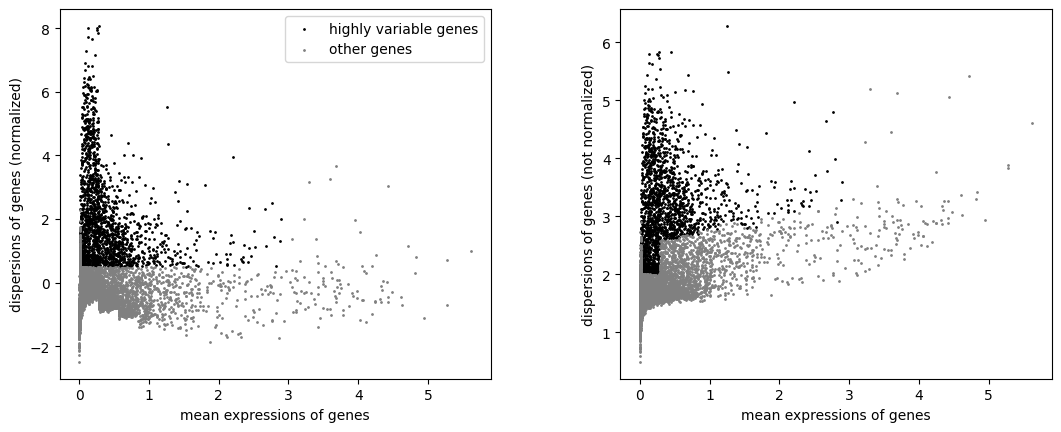

In [31]:
# Sélectionner les gènes les plus variables (les plus informatifs)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

print("Gènes hautement variables:", adata.var.highly_variable.sum())

sc.pl.highly_variable_genes(adata)

## 5. Réduction de dimension — PCA
On réduit les ~1800 gènes sélectionnés en composantes principales.
Le graphique variance ratio montre combien d'information chaque PC capture.
On garde les 10 premières PCs pour la suite.

Dimensions après sélection: (2638, 1838)


C:\Users\etulyon1\miniconda3\envs\scrna\lib\site-packages\scanpy\preprocessing\_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
C:\Users\etulyon1\miniconda3\envs\scrna\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


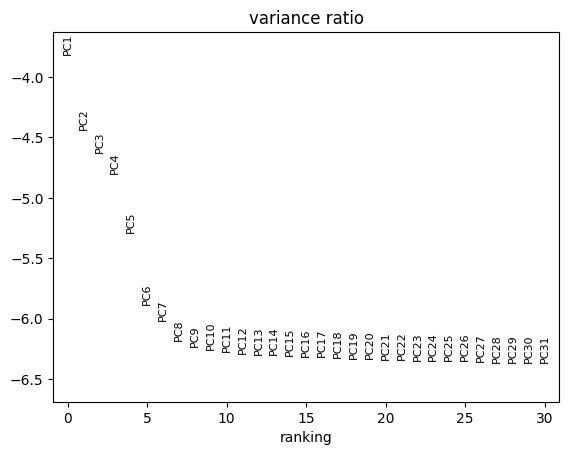

In [32]:
# Garder seulement les gènes hautement variables
adata = adata[:, adata.var.highly_variable]

print("Dimensions après sélection:", adata.shape)

# PCA
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True)

## 6. Visualisation — UMAP
On construit un graphe de voisinage entre cellules similaires,
puis on le projette en 2D avec UMAP.
Les cellules proches sur le UMAP ont un profil d'expression similaire.

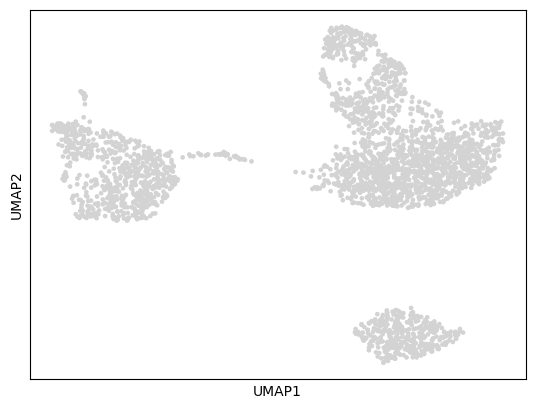

In [33]:
# Calculer le graphe de voisinage (base du clustering)
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=10)

# Calculer le UMAP
sc.tl.umap(adata)

# Visualiser
sc.pl.umap(adata)

## 7. Clustering Leiden
L'algorithme Leiden regroupe automatiquement les cellules connectées dans le graphe.
Le paramètre resolution contrôle la granularité : plus il est élevé, plus on obtient de clusters.

C:\Users\etulyon1\AppData\Local\Temp\ipykernel_7064\3509160923.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


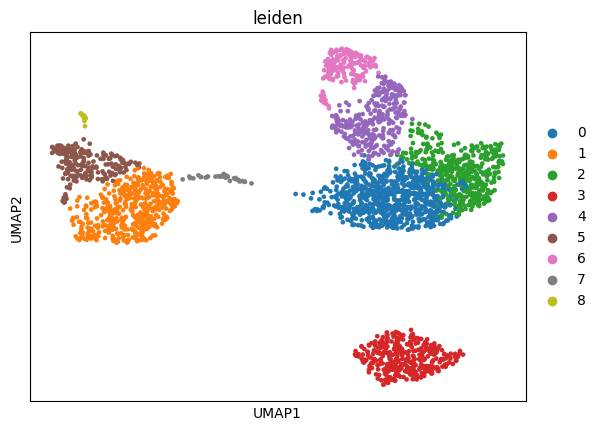

In [36]:
# Clustering Leiden
sc.tl.leiden(adata, resolution=0.5)

# Visualiser avec les clusters colorés
sc.pl.umap(adata, color='leiden')

## 8. Annotation cellulaire
On identifie les gènes marqueurs de chaque cluster,
puis on les associe aux types cellulaires connus du sang humain.

C:\Users\etulyon1\miniconda3\envs\scrna\lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\etulyon1\miniconda3\envs\scrna\lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\etulyon1\miniconda3\envs\scrna\lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\etulyon1\miniconda3\envs\scrna\lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\etulyon1\miniconda3\envs\scrna\lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] =

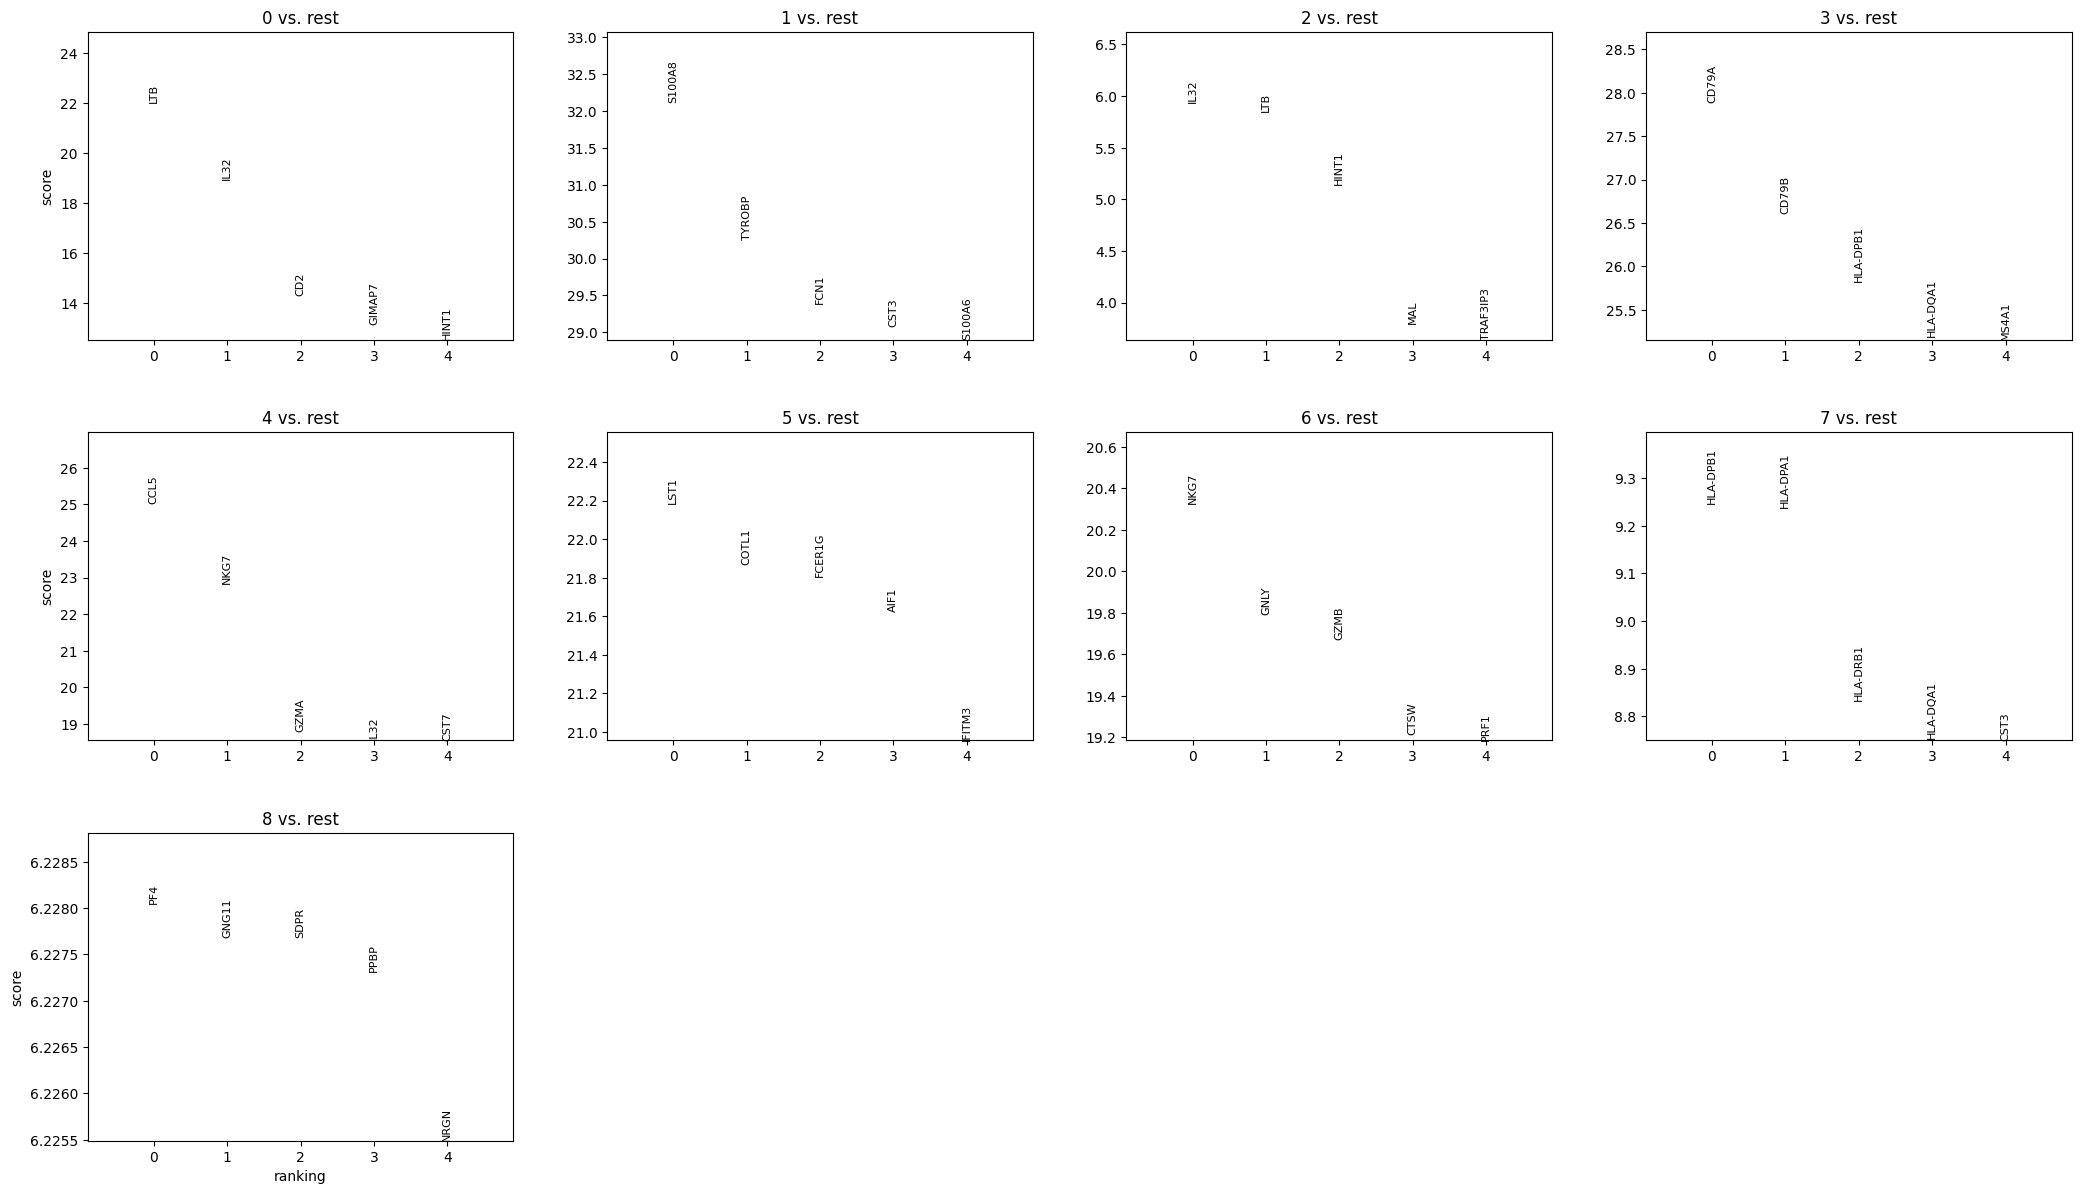

In [37]:
# Trouver les gènes les plus exprimés dans chaque cluster
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=5, sharey=False)

## Résultats
8 types cellulaires identifiés : CD4 T cells, CD14 Monocytes, B cells, CD8 T cells,
NK cells, FCGR3A Monocytes, Dendritic cells, Platelets.
Pipeline complet reproductible — voir environment.yml pour les dépendances.

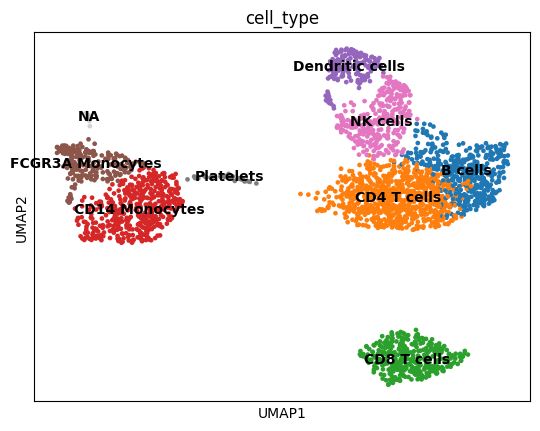

In [39]:
new_cluster_names = {
    '0': 'CD4 T cells',
    '1': 'CD14 Monocytes',
    '2': 'B cells',
    '3': 'CD8 T cells',
    '4': 'NK cells',
    '5': 'FCGR3A Monocytes',
    '6': 'Dendritic cells',
    '7': 'Platelets'
}

adata.obs['cell_type'] = adata.obs['leiden'].map(new_cluster_names)
sc.pl.umap(adata, color='cell_type', legend_loc='on data')

In [41]:
#sauvegarder
adata.write_h5ad("pbmc3k_analysed.h5ad")